In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX device:", jax.devices())
jax.config.update('jax_disable_jit', False) # Turn off JIT because of an issue in shortwave_radiation.py:169
jax.config.update("jax_debug_infs", True) # doesn't add any time since the saved time is otherwise spent getting the nodal quantities
jax.config.update("jax_debug_nans", False) # some physics fields might be nan

JAX device: [CpuDevice(id=0)]


In [2]:
import sys
from pathlib import Path

paths_check = [
    (Path(os.path.abspath(".")) / ".." / ".." / "jax-gcm").resolve(),
    (Path(os.path.abspath(".")) / "..").resolve(),
]

for module_path in paths_check:
    module_path = str(module_path)
    if module_path in sys.path:
        print("Path exist: ", module_path)
    else:
        print("Add Path: ", module_path)
        sys.path.append(module_path)


Add Path:  /home/t2hsu/projects/jax-gcm
Add Path:  /home/t2hsu/projects/jax-esm


In [3]:
import jcm
from jcm.model import Model, get_coords
from jcm.boundaries import initialize_boundaries

# Run the speedy model

In [4]:
boundary_file = (Path(os.path.abspath(".")) / ".." / ".." / "jax-gcm" / "jcm/data/bc/t30/clim/boundaries_daily.nc").resolve()
realistic_boundaries = lambda coords=get_coords(): initialize_boundaries(
    str(boundary_file),
    coords.horizontal,
)

In [5]:
import time

t0 = time.time()
model = Model(
    save_interval=2,
    total_time=4,
    # boundaries=realistic_boundaries(),
)

state = model.get_initial_state()
final_state, predictions = model.unroll(state)

t1 = time.time()

total_time = t1-t0
print(f"Total time: {total_time:.1f} s.")

Total time: 25.9 s.


In [6]:
pred_ds = model.predictions_to_xarray(predictions)

In [7]:
print(f"dataset size: {pred_ds.nbytes/1e6:.1f}MB")

dataset size: 7.3MB


In [8]:
pred_ds

<xarray.Dataset> Size: 7MB
Dimensions:                          (time: 2, lon: 96, lat: 48, level: 8)
Coordinates:
  * lon                              (lon) float64 768B 0.0 3.75 ... 352.5 356.2
  * lat                              (lat) float64 384B -87.16 -83.48 ... 87.16
  * level                            (level) float32 32B 0.95 0.835 ... 0.025
  * time                             (time) datetime64[ns] 16B 2000-01-01 200...
Data variables: (12/79)
    surface_flux.vstr.0              (time, lon, lat) float32 37kB ...
    mod_radcon.flux.2                (time, lon, lat) float32 37kB ...
    mod_radcon.stratc.1              (time, lon, lat) float32 37kB ...
    longwave_rad.ftop                (time, lon, lat) float32 37kB ...
    humidity.rh                      (time, level, lon, lat) float32 295kB ...
    surface_flux.hfluxn.1            (time, lon, lat) float32 37kB ...
    ...                               ...
    shortwave_rad.gse                (time, lon, lat) float32 37kB ...
    surface_flux.rlus.2              (time, lon, lat) float32 37kB ...
    shortwave_rad.cloudstr           (time, lon, lat) float32 37kB ...
    surface_flux.tsfc                (time, lon, lat) float32 37kB ...
    condensation.dtlsc               (time, level, lon, lat) float32 295kB ...
    u_wind                           (time, level, lon, lat) float32 295kB ...
Attributes:
    longitude_wavenumbers:     32
    total_wavenumbers:         33
    longitude_nodes:           96
    latitude_nodes:            48
    latitude_spacing:          gauss
    longitude_offset:          0.0
    radius:                    6371220.0
    spherical_harmonics_impl:  RealSphericalHarmonics
    spmd_mesh:                 
    boundaries:                [0.0, 0.05000000074505806, 0.14000000059604645...
    horizontal_grid_type:      Grid
    vertical_grid_type:        SigmaCoordinates

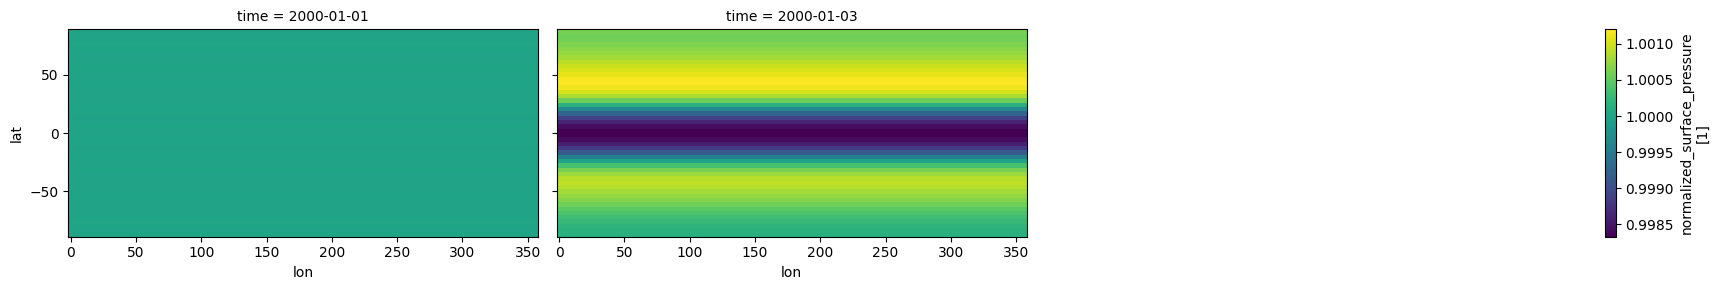

In [9]:
pred_ds['normalized_surface_pressure'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

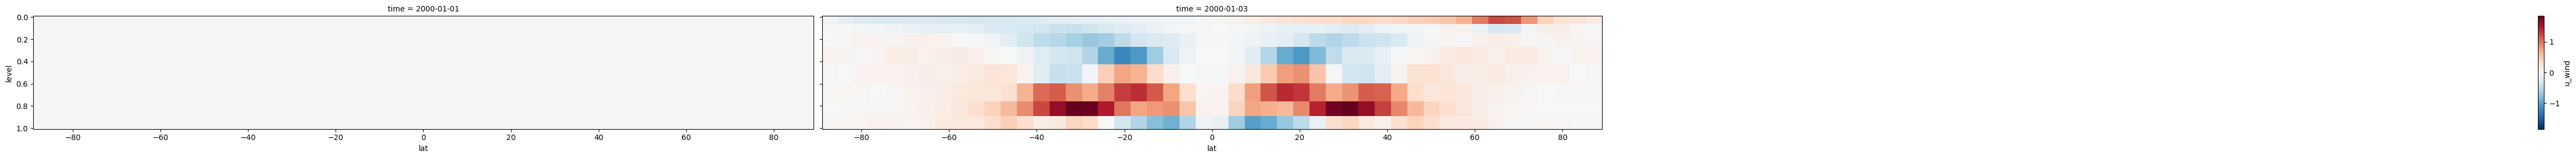

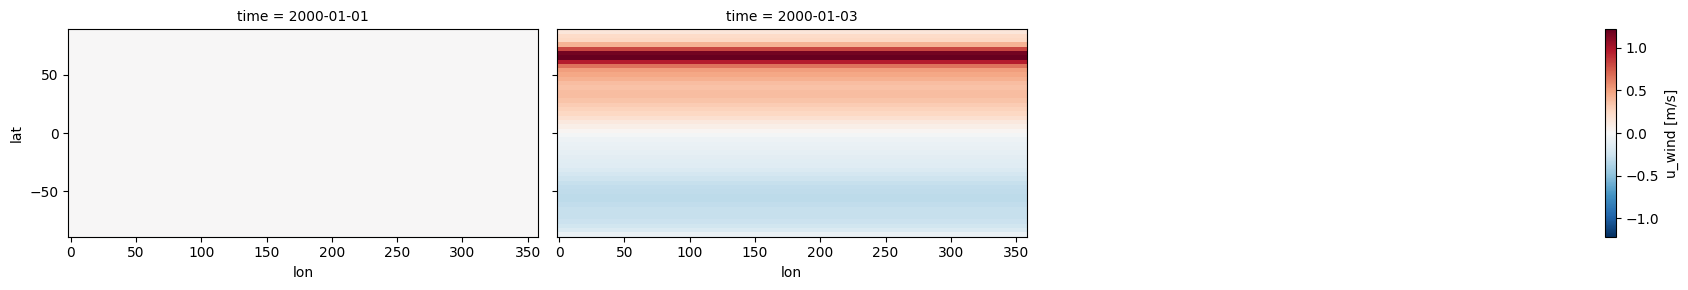

In [10]:
pred_ds['u_wind'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
pred_ds['u_wind'].isel(level=-1).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

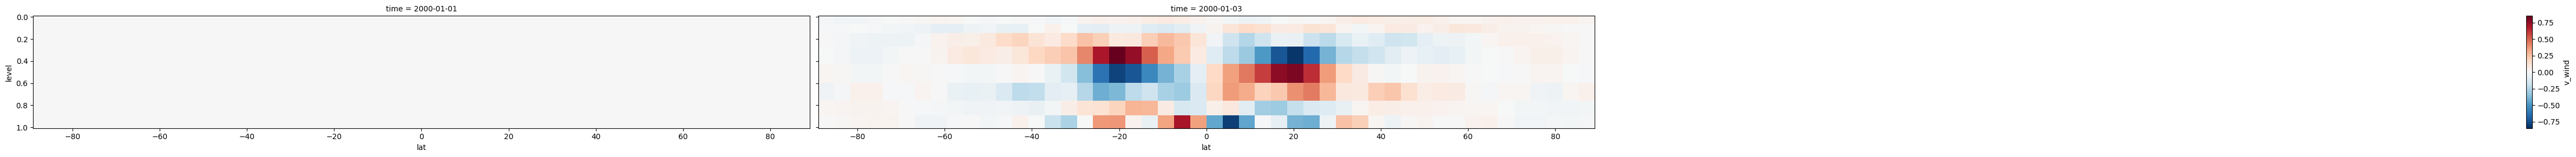

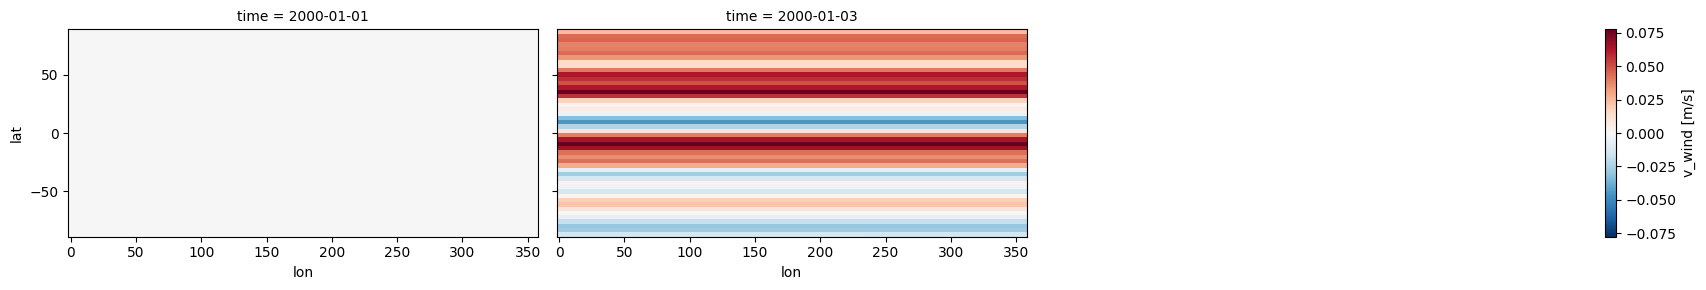

In [11]:
pred_ds['v_wind'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
pred_ds['v_wind'].isel(level=-1).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

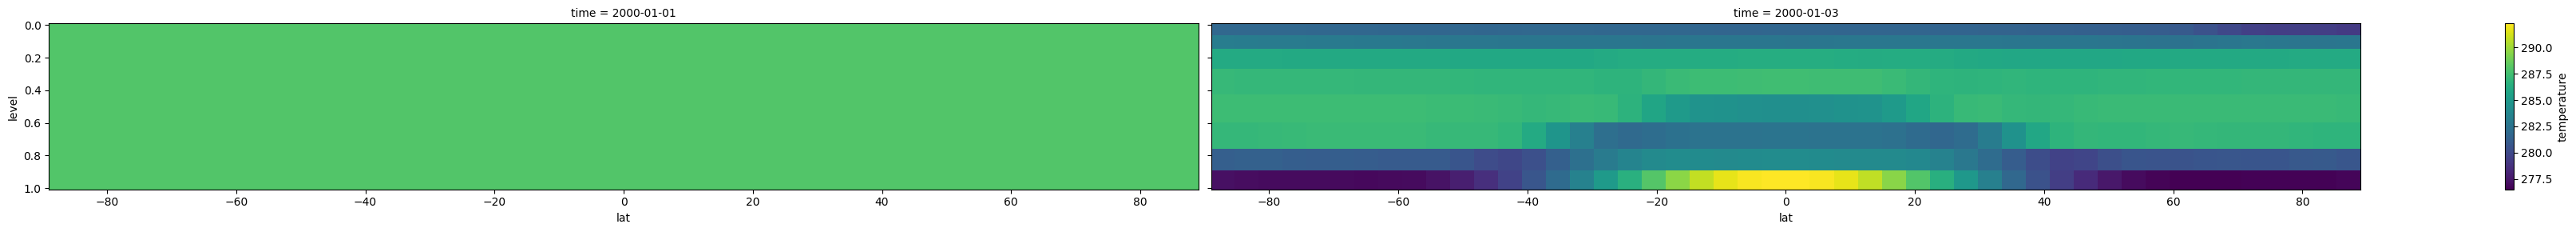

In [12]:
pred_ds['temperature'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=2, aspect=6, yincrease=False)

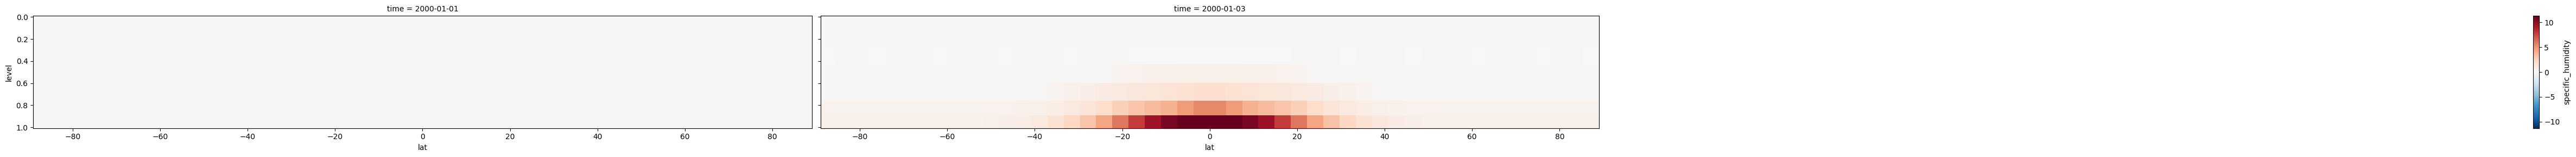

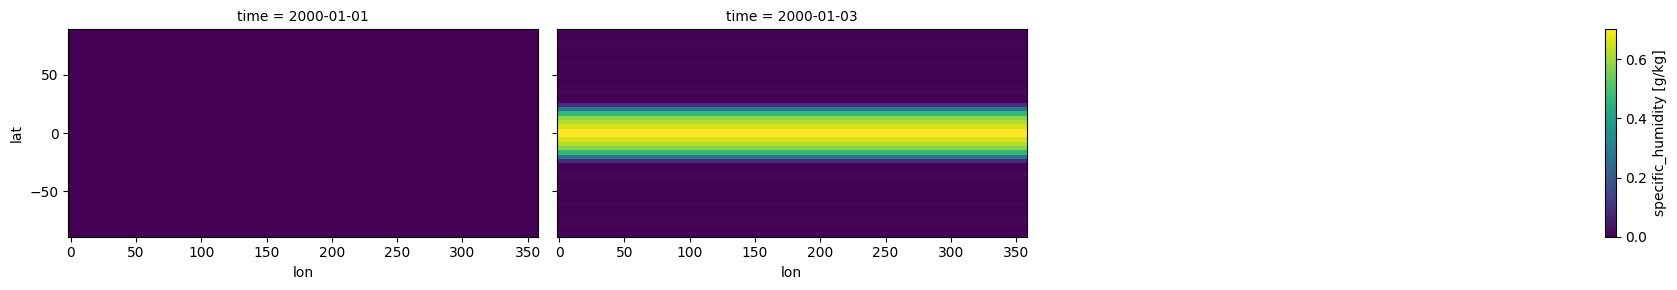

In [13]:
pred_ds['specific_humidity'].mean('lon').plot(x='lat', y='level', col='time', col_wrap=3, aspect=6, yincrease=False)
pred_ds['specific_humidity'].isel(level=3).plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

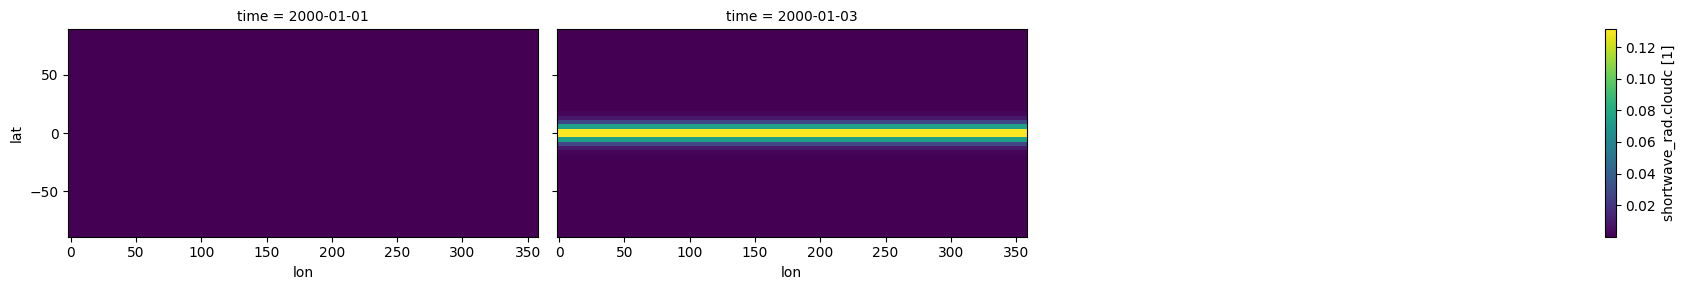

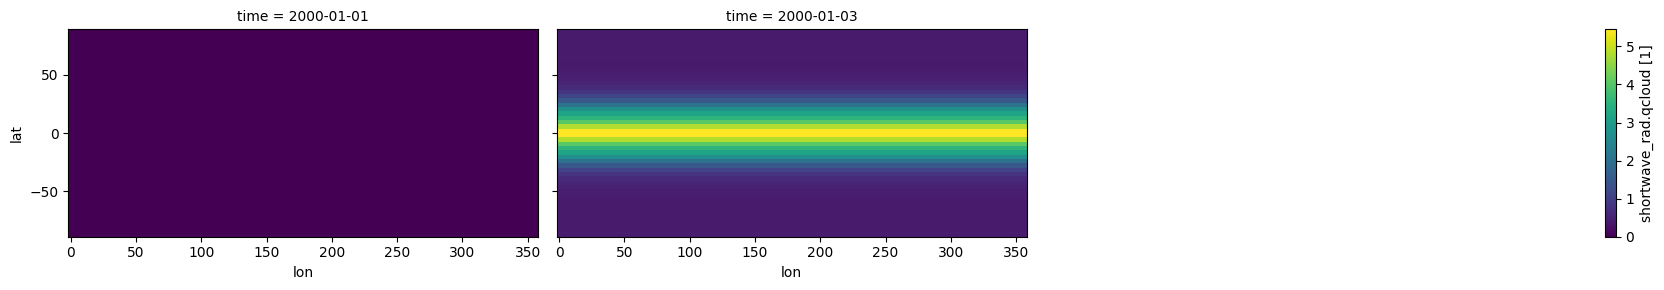

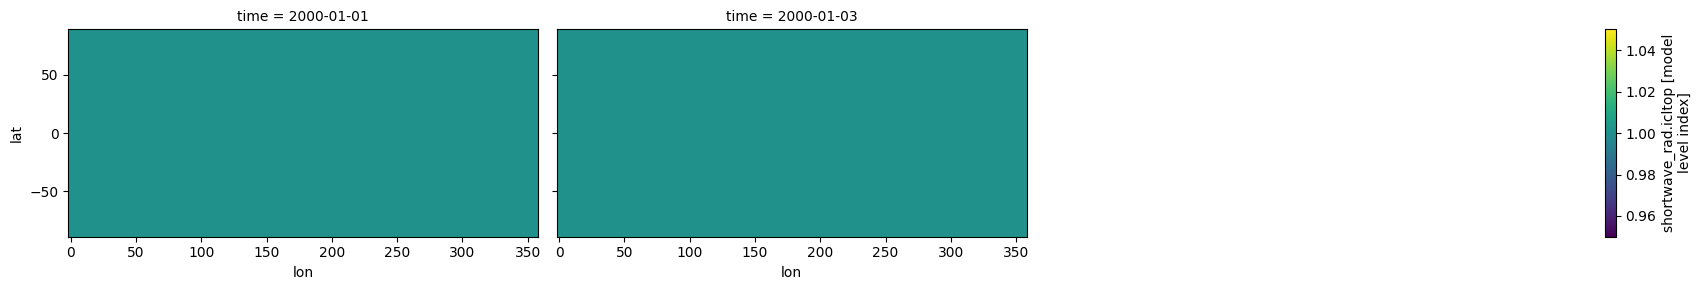

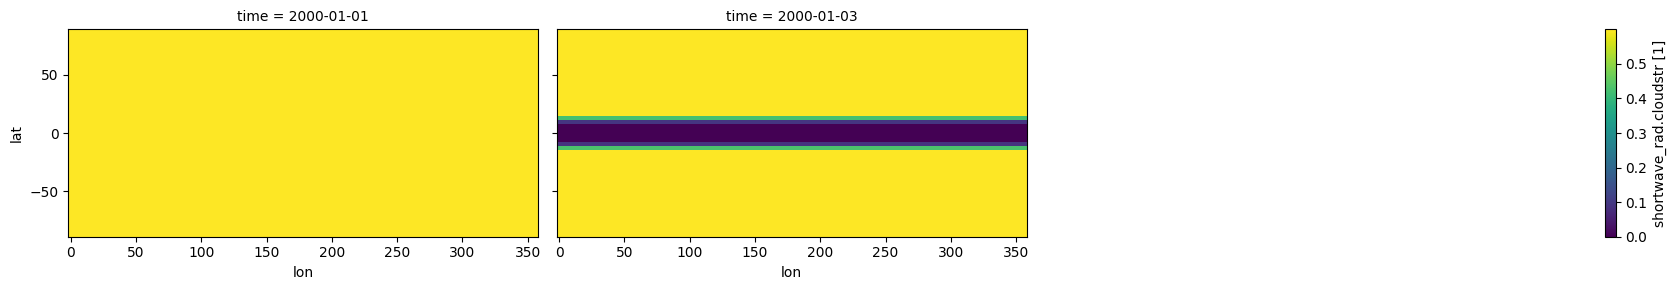

In [14]:
pred_ds['shortwave_rad.cloudc'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)
pred_ds['shortwave_rad.qcloud'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)
pred_ds['shortwave_rad.icltop'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)
pred_ds['shortwave_rad.cloudstr'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)

In [17]:
# Second time

t0 = time.time()

final_state, predictions = model.unroll(final_state)

t1 = time.time()

total_time = t1-t0
print(f"Total time: {total_time:.1f} s.")

Total time: 21.2 s.


In [20]:
pred_ds = model.predictions_to_xarray(predictions)


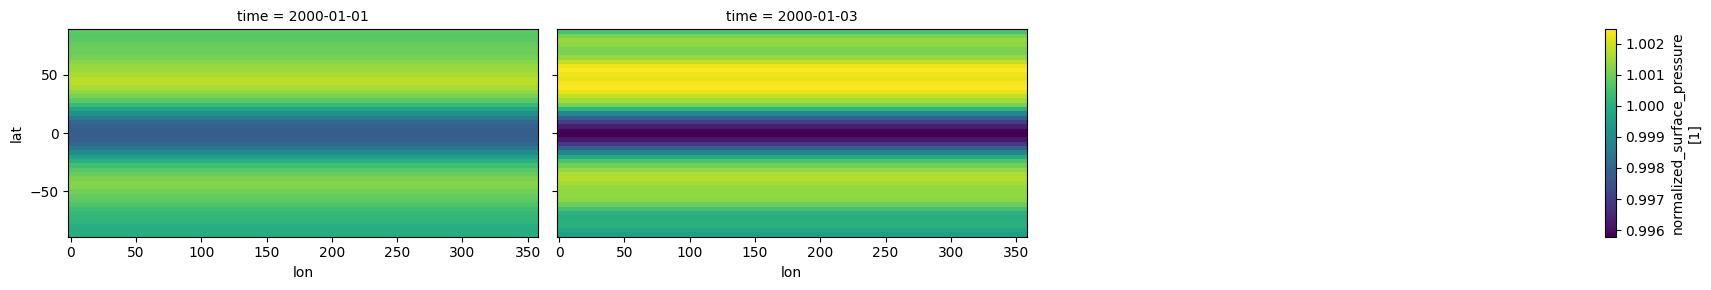

In [21]:
pred_ds['normalized_surface_pressure'].plot(x='lon', y='lat', col='time', col_wrap=3, aspect=2)